<img src=../figures/Brown_logo.svg width=50%>

## Data-Driven Design & Analyses of Structures & Materials (3dasm)

## Short Course - Lecture 2: Linear Regression

### Miguel A. Bessa | <a href = "mailto: miguel_bessa@brown.edu">miguel_bessa@brown.edu</a>  | Associate Professor

## Outline for Today

**Part I: Introduction to Linear Regression**
- Motivation: Car stopping distance problem
- Linear regression with scikit-learn
- Polynomial basis functions, underfitting vs. overfitting

**Part II: Practical Machine Learning**
- Noiseless vs. noisy datasets
- Train/test split, error metrics (MSE, R²)

**Part III: Theory and Beyond**
- Deriving the Least Squares solution step by step
- Outlier sensitivity
- Ridge regression and Bayesian linear regression
- Summary and key takeaways

In [1]:
# Basic imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Math

%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8,4)

# Scikit-learn imports
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

---
# Part I: Introduction to Linear Regression

*A practical introduction to training linear models with scikit-learn*

## Today's lecture is going to mix practice with theory

Since we covered the fundamentals of Bayesian and non-Bayesian machine learning in Lecture 1 of this short course...

* Today we will focus on how to train **linear regression models** using [scikit-learn](https://scikit-learn.org).

* We will also derive the models that we are covering today, but that will happen after we use scikit-learn.

## Loading data with Pandas

Let's load a dataset for the car stopping distance problem:

In [2]:
# Load data from CSV file
car_prob_df = pd.read_csv("../data/data_for_car_prob.csv", index_col=0)
print(car_prob_df.head(10))  # Show first 10 rows

           x           y
0   9.516939   29.749036
1  72.398757  642.132203
2  17.950326   36.648484
3   9.440853   18.604106
4  78.791008  769.656168
5  16.961121   57.971010
6  65.410368  559.093313
7  58.671099  463.686613
8  21.550603   92.242676
9  36.866913  197.688573


In [3]:
# Separate into inputs (x) and outputs (y)
Data_x = car_prob_df['x'].values
Data_y = car_prob_df['y'].values
print("Data_x shape:", Data_x.shape)
print("Data_y shape:", Data_y.shape)

Data_x shape: (50,)
Data_y shape: (50,)


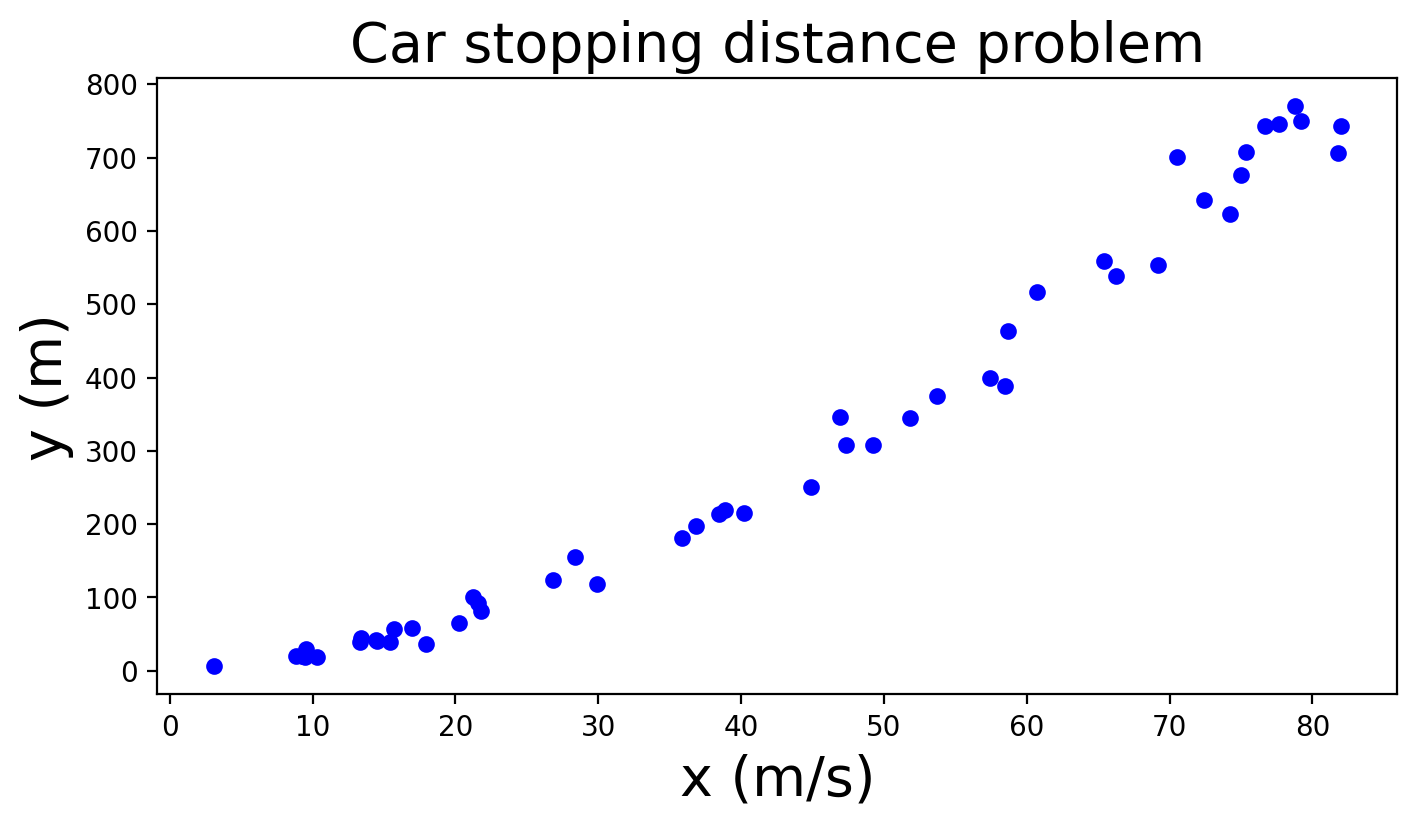

In [4]:
fig_car_data, ax_car_data = plt.subplots()
ax_car_data.plot(Data_x, Data_y, 'b.', markersize=10)
ax_car_data.set_xlabel("x (m/s)", fontsize=20)
ax_car_data.set_ylabel("y (m)", fontsize=20)
ax_car_data.set_title("Car stopping distance problem", fontsize=20);

## Supervised learning: regression models

When we do regression via supervised learning we want to:

* Create a machine learning model
* Train it on known data (known inputs $x$ and outputs $y$)
* Predict for new (unseen) data points, i.e. predict $y^*$ for a new value of $x^*$.

Today we will talk about the simplest models: **linear regression**.

## Linear regression models

Linear regression models encompass a class of machine learning methods that is larger than you might think...

As we will see, despite being called "linear" these models can do more than fitting a simple "line" to our data.

## Simplest 1D linear regression model

1. **Observation distribution** (usually Gaussian):

$$p(y|x, \mathbf{z}) = \mathcal{N}(y| \mu_{y|z} = \mathbf{w}^T \boldsymbol{\phi}(x), \sigma_{y|z}^2 = \sigma^2)$$

where:
* $\mathbf{z} = (\mathbf{w}, \sigma)$ are the model parameters
* $\mathbf{w} = [w_0, w_1]^T$ includes the **bias** $w_0$ and **weight** $w_1$
* $\boldsymbol{\phi}(x) = [1, x]^T$ are the **basis functions**

2. A chosen **Prior distribution** on the parameters $\mathbf{z}$

## Polynomial basis functions

The basis functions $\boldsymbol{\phi}(x)$ don't need to be linear!

For a polynomial of degree $d$:
$$\boldsymbol{\phi}(x) = [1, x, x^2, ..., x^d]^T$$

As long as the basis functions don't depend on the unknown parameters, the model remains **linear in the parameters**.

That's why we still call this a **linear model**.

## Linear regression from a Bayesian perspective

The choice of likelihood and prior determines the model!

| Likelihood | Prior (on weights) | Posterior | Name |
|---|---|---|---|
| Gaussian | Uniform | Point estimate | **Least Squares** |
| Gaussian | Gaussian | Point estimate | **Ridge** |
| Gaussian | Laplace | Point estimate | **Lasso** |
| Gaussian | Gaussian | Gaussian | **Bayesian Linear Regression** |

We will focus on the practical aspects first, then derive these models!

## Training a linear model with Scikit-learn

<img src="../figures/reaction-braking-stopping.svg" title="Car stopping distance" width="40%" align="right">

Let's train a simple linear regression model:

**Least Squares Regression** (Gaussian likelihood, Uniform prior, Point estimate)

**Polynomial of degree 1** (a straight line)

In [5]:
# Define the model (polynomial basis + Least Squares Regression)
degree = 1
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

**Important:** Scikit-learn expects inputs as a 2D array (matrix), not a 1D vector.

In [6]:
# Reshape input vector into 2D array
Data_X = np.reshape(Data_x, (-1, 1))

# Train (fit) the model
poly_model.fit(Data_X, Data_y)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,1
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


## Making predictions

Now that we have a trained model, we can predict $y^*$ for any new input $x^*$.

In [7]:
# Predict for training points
y_pred = poly_model.predict(Data_X)

# Create points for plotting the model
x_plot = np.linspace(0, 90, 200)
y_plot = poly_model.predict(np.reshape(x_plot, (-1, 1)))

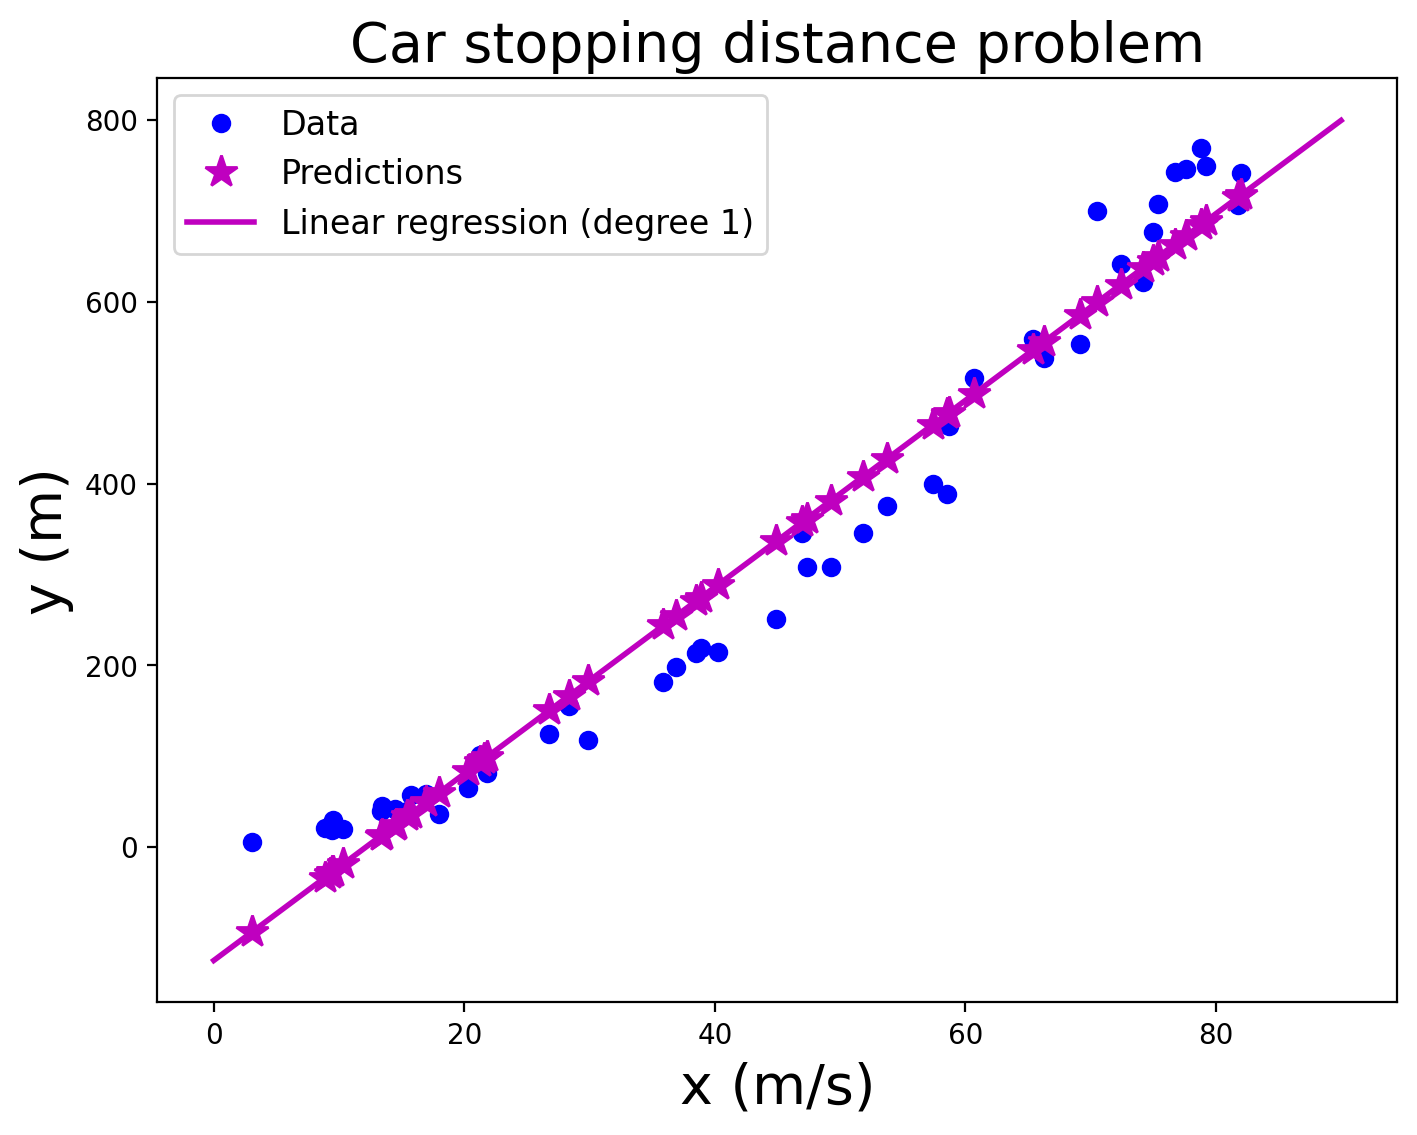

In [8]:
# Plot everything
fig_poly, ax_poly = plt.subplots()
ax_poly.plot(Data_x, Data_y, 'b.', markersize=12, label="Data")
ax_poly.plot(Data_x, y_pred, 'm*', markersize=12, label="Predictions")
legend_str = f"Linear regression (degree {degree})"
ax_poly.plot(x_plot, y_plot, 'm-', linewidth=2, label=legend_str)
ax_poly.set_xlabel("x (m/s)", fontsize=20)
ax_poly.set_ylabel("y (m)", fontsize=20)
ax_poly.set_title("Car stopping distance problem", fontsize=20)
ax_poly.legend(loc='upper left', fontsize=12)
fig_poly.set_size_inches(8, 6)

## In-class Exercise

1. Put it all together and create a linear model using a **polynomial of degree 2** for the same data.

2. Compare your plot with the one obtained for the straight line (polynomial of degree 1).

3. Play a bit with your code by **changing the degree** of the polynomial. What happens?

In [9]:
# Write your code for In-class Exercise:

# until here.

<details>
<summary><b>Click here for Solution</b></summary>

```python
degree = 2
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(np.reshape(Data_x, (-1, 1)), Data_y)
y_pred = poly_model.predict(Data_X)
x_plot = np.linspace(0, 90, 200)
y_plot = poly_model.predict(np.reshape(x_plot, (-1, 1)))
fig_poly, ax_poly = plt.subplots()
ax_poly.plot(Data_x, Data_y, 'b.', markersize=12, label="Data")
ax_poly.plot(Data_x, y_pred, 'm*', markersize=12, label="Predictions")
ax_poly.plot(x_plot, y_plot, 'm-', linewidth=2, label=f"Polynomial degree {degree}")
ax_poly.set_xlabel("x (m/s)", fontsize=20)
ax_poly.set_ylabel("y (m)", fontsize=20)
ax_poly.legend(loc='upper left')
```
</details>

## Overfitting

When you increase the polynomial degree too much, the prediction gets worse!

This is called **overfitting**: having a model that is more complex than it should be.

The "true" car stopping distance follows a quadratic model: $y = z_1 x + z_2 x^2$
* We don't need additional complexity!

## Interpolation vs. Extrapolation

The fit is better **within the training domain** ($x\in [3, 83]$) than away from it.

* We **interpolate** better than we **extrapolate**.

* Nevertheless, overfitting is also an issue when interpolating!
  - Try degree 30 and plot for $x\in [5, 80]$

---
# Part II: Practical Considerations

*Dealing with noise, train/test splits, and error metrics*

## Example: Linear model for a noiseless problem

Consider the function $f(x) = x\sin(x)$ in the domain $x\in[0,10]$.

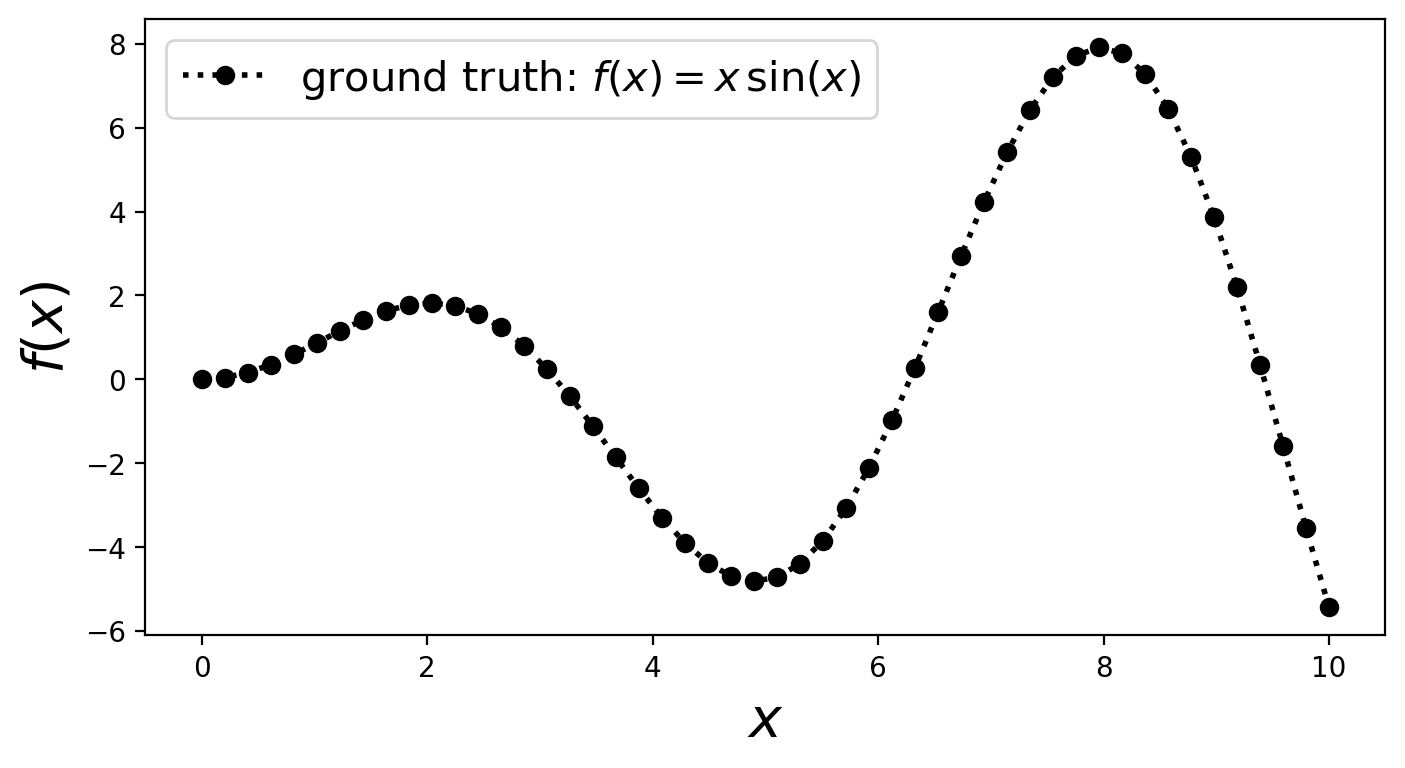

In [10]:
# Define the function f(x) = x sin(x)
def f(x):
    return x * np.sin(x)
# Create data
n_data = 50
x_data = np.linspace(0, 10, n_data)
y_data = f(x_data)
# Plot
fig1, ax1 = plt.subplots()
ax1.plot(x_data, y_data, 'ko:', markersize=6, linewidth=2, label=r'ground truth: $f(x) = x\, \sin(x)$')
ax1.set_xlabel('$x$', fontsize=20)
ax1.set_ylabel('$f(x)$', fontsize=20)
ax1.legend(loc='upper left', fontsize=15)
fig1.set_size_inches(8, 4)

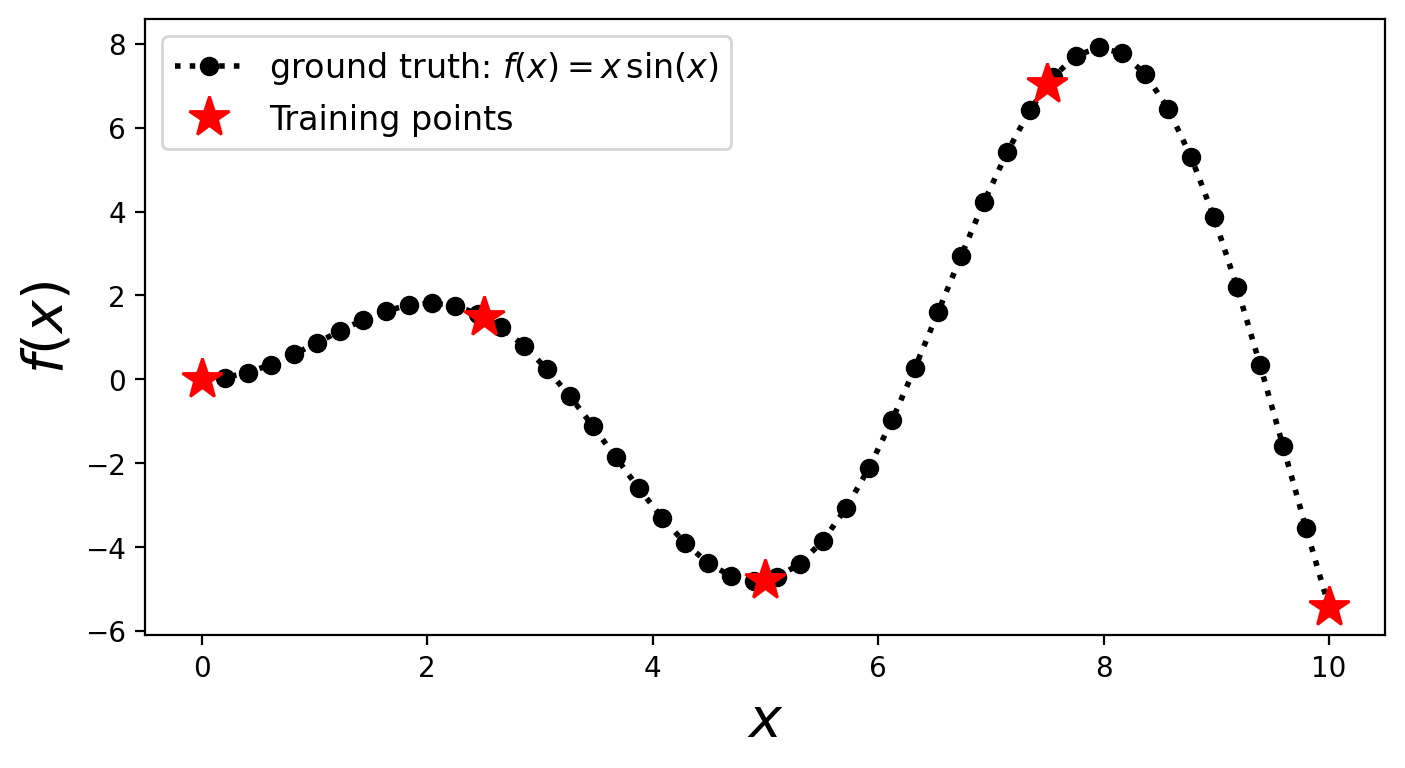

In [11]:
# What if we only have a few training points?
n_train = 5
x_train = np.linspace(0, 10, n_train)
y_train = f(x_train)

ax1.plot(x_train, y_train, 'r*', markersize=15, label="Training points")
ax1.legend(loc='upper left', fontsize=12)
fig1

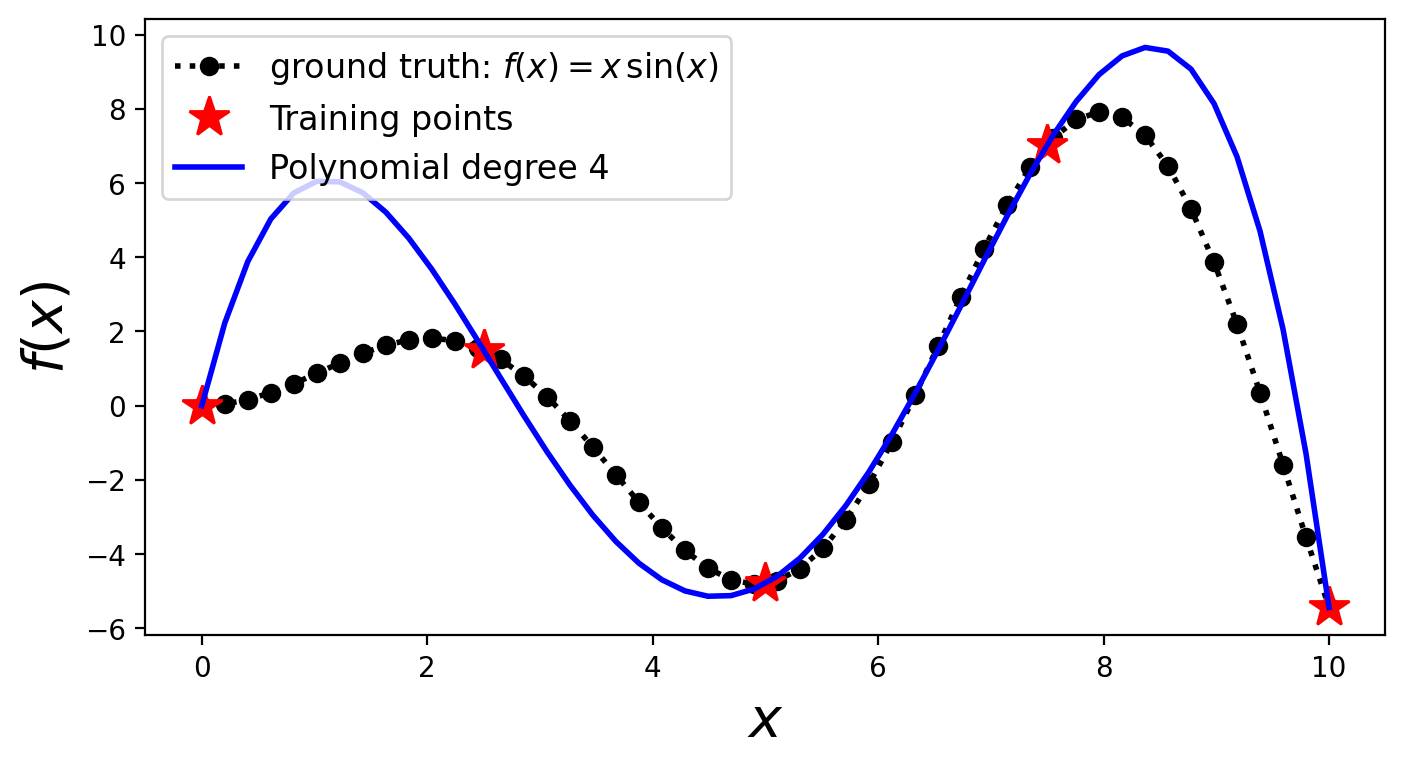

In [12]:
# Fit a polynomial of degree 4
degree = 4
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
X_train = np.reshape(x_train, (-1, 1))
poly_model.fit(X_train, y_train)

# Predict
X_data = np.reshape(x_data, (-1, 1))
y_pred = poly_model.predict(X_data)

ax1.plot(x_data, y_pred, 'b-', linewidth=2, label=f"Polynomial degree {degree}")
ax1.legend(loc='upper left', fontsize=12)
fig1

## How do we evaluate the quality of our model?

By evaluating the error on points **not used for training**.

Common metrics:
* **MSE** (Mean Squared Error): lower is better
* **R²** (Coefficient of determination): closer to 1 is better

In [13]:
# Compute MSE and R² for the polynomial model
mse_value = mean_squared_error(y_data, y_pred)
r2_value = r2_score(y_data, y_pred)

print(f'MSE = {mse_value:.4f}')
print(f'R² score = {r2_value:.4f}')

MSE = 5.8270
R² score = 0.5787


## Linear model for noisy datasets

Let's consider a case where we perturb $f(x) = x\sin(x)$ with noise.

This is similar to what happens in the car stopping distance problem.

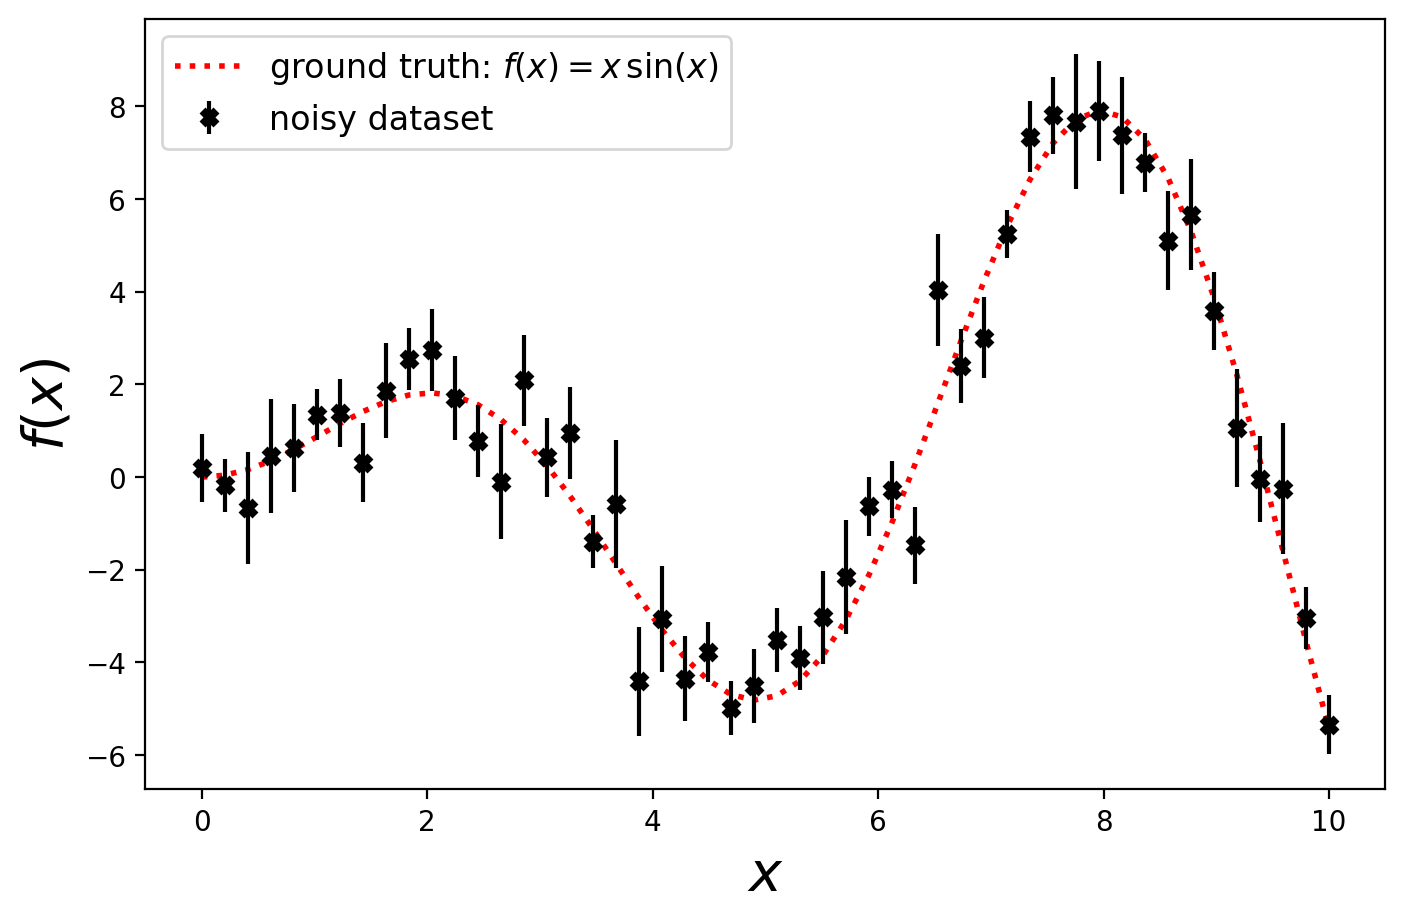

In [14]:
seed = 1987
np.random.seed(seed)

# Create noisy data
random_std = 0.5 + 1.0 * np.random.random(y_data.shape)
noise = np.random.normal(0, random_std)
y_noisy_data = y_data + noise

# Plot
fig2, ax2 = plt.subplots()
ax2.plot(x_data, y_data, 'r:', linewidth=2, label=r'ground truth: $f(x) = x\,\sin(x)$')
ax2.errorbar(x_data, y_noisy_data, random_std, fmt='kX', markersize=6, label='noisy dataset')
ax2.set_xlabel('$x$', fontsize=20)
ax2.set_ylabel('$f(x)$', fontsize=20)
ax2.legend(loc='upper left', fontsize=12)
fig2.set_size_inches(8, 5)

## Train/Test Split

To test our model, we need to use data that we **haven't used for training**!

We split the dataset into:
1. **Training set** (e.g., 75% of data) - used to fit the model
2. **Test set** (remaining 25%) - used to evaluate the model

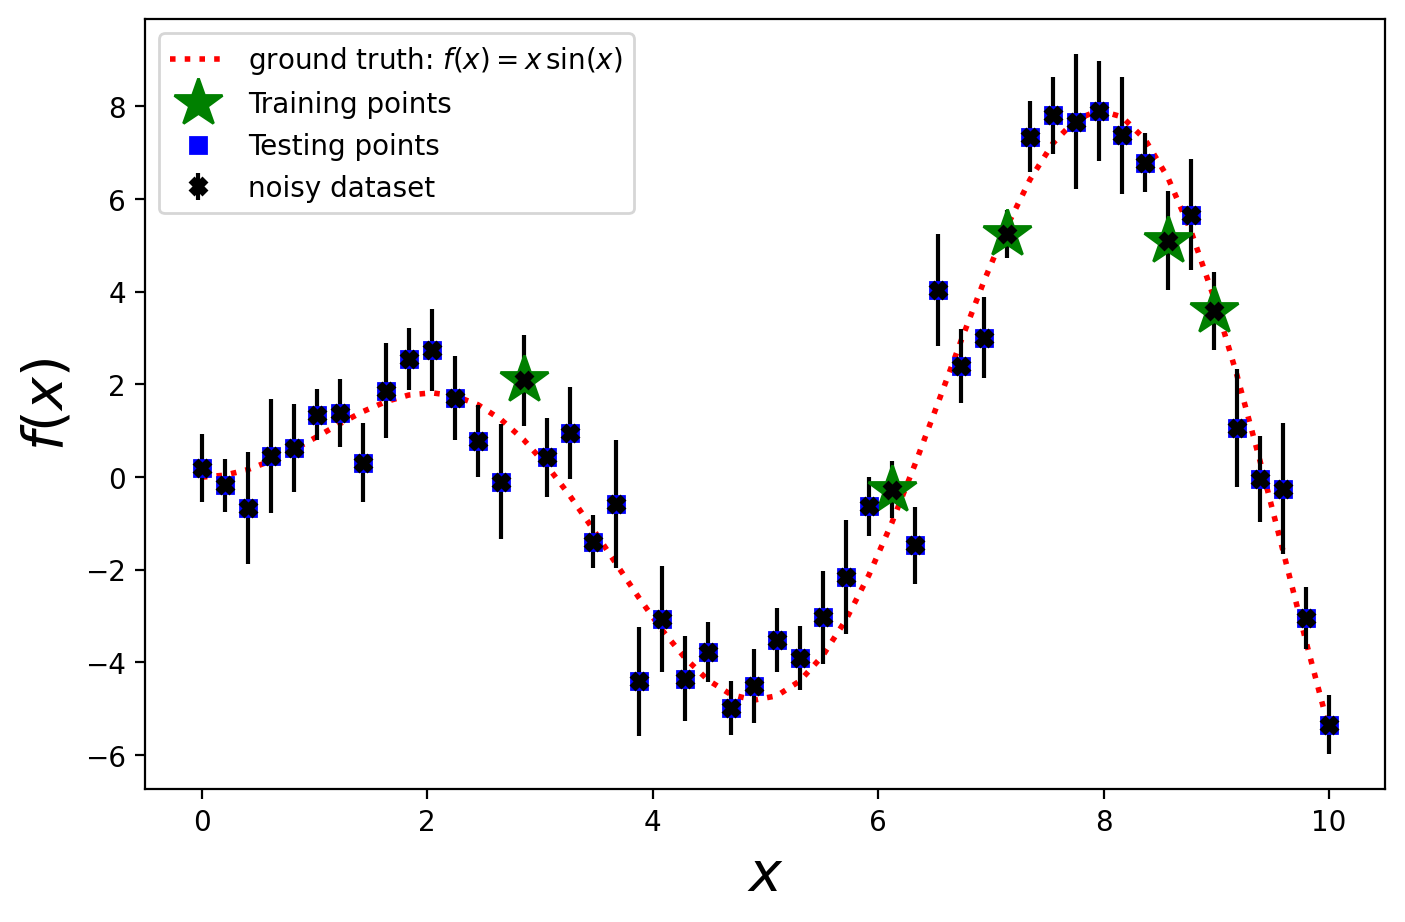

In [15]:
# Split the data
X_data = np.reshape(x_data, (-1, 1))
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_noisy_data, test_size=0.90, random_state=seed
)

# Visualize the split
ax2.plot(X_train, y_train, 'g*', markersize=18, label="Training points")
ax2.plot(X_test, y_test, 'bs', markersize=6, label="Testing points")
ax2.legend(loc='upper left', fontsize=10)
fig2

## In-class Exercise

Fit a polynomial of degree 4 to the training data and calculate the $R^2$ and MSE metrics on the **testing data**.

In [16]:
# Write your code for In-class Exercise:

# until here.

<details>
<summary><b>Click here for Solution</b></summary>

```python
degree = 4
poly_model2 = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model2.fit(X_train, y_train)
y_pred = poly_model2.predict(X_test)

mse_value = mean_squared_error(y_test, y_pred)
r2_value = r2_score(y_test, y_pred)
print(f'MSE = {mse_value:.4f}')
print(f'R² score = {r2_value:.4f}')
```
</details>

---
# Part III: Theory and Beyond

*From Least Squares to regularization and uncertainty quantification*

## Summary of Linear Least Squares model

| Likelihood | Prior | Posterior | Name |
|---|---|---|---|
| Gaussian | Uniform | Point estimate (MLE) | **Least Squares** |

1. **Observation distribution**: $p(y|\mathbf{x}, \mathbf{z}) = \mathcal{N}(y| \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}), \sigma^2)$

2. **Uniform prior**: $p(\mathbf{z}) \propto 1$

3. **MLE point estimate**: $\hat{\mathbf{z}}_{\text{mle}} = \underset{z}{\mathrm{argmin}}\left[-\sum_{n=1}^{N}\log{ p(y_n|\mathbf{x}_n, \mathbf{z})}\right]$

## Deriving the Least Squares solution

Since our observation distribution is Gaussian, the negative log-likelihood is:

$$
\begin{align}
\hat{\mathbf{z}}_{\text{mle}} &= \underset{z}{\mathrm{argmin}}\left[-\sum_{n=1}^{N}\log{ p(y=y_n|\mathbf{x}=\mathbf{x}_n, \mathbf{z})}\right] \\
&= \underset{z}{\mathrm{argmin}}\left[-\sum_{n=1}^{N}\log{\left( \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left\{ -\frac{1}{2\sigma^2}\left[y_n-\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n)\right]^2\right\}\right)}\right]\\
&= \underset{z}{\mathrm{argmin}}\left[\frac{N}{2}\log{\left(2\pi \sigma^2\right)}+\frac{1}{2 \sigma^2}\sum_{n=1}^{N}\left[y_n-\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n)\right]^2 \right]\\
\end{align}
$$

where we recall that the unknowns are $\mathbf{z} = (\mathbf{w}, \sigma)$.

## Taking the gradient and setting it to zero

To find the minimum we set $\nabla_{\mathbf{w}} \text{NLL}(\mathbf{w}, \sigma^2) = \mathbf{0}$, which gives:

$$\begin{align}
\nabla_{\mathbf{w}} \left[\frac{N}{2}\log{\left(2\pi \sigma^2\right)}+\frac{1}{2 \sigma^2}\sum_{n=1}^{N}\left[y_n-\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n)\right]^2 \right] = \mathbf{0} \\
\nabla_{\mathbf{w}} \left[\underbrace{\frac{1}{2}\sum_{n=1}^{N}\left[y_n-\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n)\right]^2}_{\text{RSS}(\mathbf{w})} \right] = \mathbf{0}
\end{align}
$$

The constant terms and $\frac{1}{\sigma^2}$ drop out! We only need to minimize the **Residual Sum of Squares** (RSS).

## Introducing the design matrix

We can rewrite the RSS in matrix form:

$$
\nabla_{\mathbf{w}} \left[\frac{1}{2}\left(\boldsymbol{\Phi}\mathbf{w} - \mathbf{y}\right)^T \left(\boldsymbol{\Phi}\mathbf{w} - \mathbf{y}\right) \right] = \mathbf{0}
$$

where $\mathbf{y}$ groups all outputs and $\boldsymbol{\Phi}$ is the $N\times M$ **design matrix**:

$$
\boldsymbol{\Phi} = \begin{bmatrix} \phi_0(\mathbf{x}_1) & \phi_1(\mathbf{x}_1) & \cdots & \phi_{M-1}(\mathbf{x}_1) \\
\phi_0(\mathbf{x}_2) & \phi_1(\mathbf{x}_2) & \cdots & \phi_{M-1}(\mathbf{x}_2) \\
\vdots & \vdots & \ddots & \vdots \\
\phi_0(\mathbf{x}_N) & \phi_1(\mathbf{x}_N) & \cdots & \phi_{M-1}(\mathbf{x}_N) \\
\end{bmatrix}
$$

## Solving for the weights

Using the matrix calculus identity $\frac{\partial \mathbf{u}^T\mathbf{A}\mathbf{u}}{\partial \mathbf{u}} = \left( \mathbf{A}+\mathbf{A}^T\right)\mathbf{u}$:

$$\begin{align}
\frac{1}{2} \left[ \left( \boldsymbol{\Phi}^T\boldsymbol{\Phi}+\boldsymbol{\Phi}^T\boldsymbol{\Phi} \right)\mathbf{w} -\boldsymbol{\Phi}^T\mathbf{y}-\boldsymbol{\Phi}^T\mathbf{y} \right] = \mathbf{0}
\end{align}
$$

From which we reach the MLE estimate for the weights:

$$
\boxed{\hat{\mathbf{w}}_{\text{mle}} = \left(\boldsymbol{\Phi}^T \boldsymbol{\Phi} \right)^{-1} \boldsymbol{\Phi}^T \mathbf{y}}
$$

## Estimating the noise variance

Solving $\nabla_{\sigma^2} \text{NLL}(\mathbf{w}, \sigma^2) = 0$ gives:

$$
\hat{\sigma}_{\text{mle}}^2 = \frac{1}{N}\sum_{n=1}^{N} \left[y_n -\hat{\mathbf{w}}^T_{\text{mle}}\boldsymbol{\phi}(\mathbf{x}_n)\right]^2
$$

This is simply the **mean squared residual** — the average squared difference between observations and predictions.

In practice, scikit-learn computes $\hat{\mathbf{w}}_{\text{mle}}$ efficiently using SVD (Singular Value Decomposition).

## Moore-Penrose pseudo-inverse

The quantity

$$\boldsymbol{\Phi}^{\dagger} = \left(\boldsymbol{\Phi}^T \boldsymbol{\Phi} \right)^{-1} \boldsymbol{\Phi}^T$$

is called the **Moore-Penrose pseudo-inverse** of $\boldsymbol{\Phi}$.

* Generalizes matrix inverse to non-square matrices
* In the special case of $\boldsymbol{\Phi}$ being square and invertible: $\boldsymbol{\Phi}^{\dagger}=\boldsymbol{\Phi}^{-1}$
* If $N = M$, the solution is unique and the training error becomes zero

## Sensitivity to outliers

**Important:** Least Squares regression is **sensitive to data outliers**.

Use the sliders below to move the red "Outlier" point and observe how the fitted line reacts.

In [17]:
from ipywidgets import interact, FloatSlider

def plot_outlier_effect(outlier_x, outlier_y):
    # Base data
    np.random.seed(42)
    x = np.linspace(0, 10, 10)
    y = 2 * x + 1 + np.random.normal(0, 1, 10)
    
    # Add outlier
    x_all = np.append(x, outlier_x)
    y_all = np.append(y, outlier_y)
    
    # Fit model (Least Squares)
    A = np.vstack([x_all, np.ones(len(x_all))]).T
    m, c = np.linalg.lstsq(A, y_all, rcond=None)[0]
    
    # Plot
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, label='Data')
    plt.scatter(outlier_x, outlier_y, color='red', s=100, label='Outlier')
    plt.plot(x_all, m*x_all + c, 'r', label=f'Fit: y = {m:.2f}x + {c:.2f}')
    plt.legend()
    plt.title("Effect of Outlier on Least Squares Fit")
    plt.grid(True)
    plt.show()

In [18]:
interact(plot_outlier_effect,
         outlier_x=FloatSlider(min=0, max=15, step=0.5, value=12, description='Outlier X'),
         outlier_y=FloatSlider(min=-10, max=50, step=1, value=0, description='Outlier Y'));

interactive(children=(FloatSlider(value=12.0, description='Outlier X', max=15.0, step=0.5), FloatSlider(value=…

## Beyond Least Squares

*Regularization and uncertainty quantification*

## Parameters vs. Hyperparameters

**Parameters**: The unknown variables $\mathbf{z}$ we want to estimate
* We either marginalize them (Bayesian) or estimate them (Point estimate)

**Hyperparameters**: Variables we specify/assume for our model
* They do not change after training
* Examples: prior parameters, observation variance, regularization strength

## Ridge Regression

| Likelihood | Prior | Posterior | Name |
|---|---|---|---|
| Gaussian | **Gaussian** | Point estimate (MAP) | **Ridge** |

Uses a **Gaussian prior** on the weights: $p(\mathbf{w}) = \mathcal{N}(\mathbf{w}| \mathbf{0}, \sigma_w^2 \mathbf{I})$

The MAP estimate minimizes:
$$\hat{\mathbf{w}}_{\text{map}} = \underset{w}{\mathrm{argmin}}\left[\text{RSS}(\mathbf{w}) + \alpha ||\mathbf{w}||_2^2\right]$$

where $||\mathbf{w}||_2^2 = \sum_m |w_m|^2$ is the $\ell_2$ norm (**L2 regularization** / **weight decay**)

## Why does regularization help?

The $\ell_2$ penalty **prevents weights from becoming too large**.

* Large weights often indicate overfitting
* Regularization keeps the model simpler
* The hyperparameter $\alpha$ controls the strength of regularization

Ridge regression solution:
$$\hat{\mathbf{w}}_{\text{map}} = \left( \boldsymbol{\Phi}^T\boldsymbol{\Phi} + \alpha \mathbf{I}_M \right)^{-1} \boldsymbol{\Phi}^T \mathbf{y}$$

## Bayesian Linear Regression

| Likelihood | Prior | Posterior | Name |
|---|---|---|---|
| Gaussian | Gaussian | **Gaussian** | **Bayesian Linear Regression** |

Instead of a point estimate, we compute the **full posterior**:

$$p(\mathbf{w}| \mathcal{D}) = \mathcal{N}(\mathbf{w}| \overset{>}{\boldsymbol{\mu}}_w, \overset{>}{\boldsymbol{\Sigma}}_w)$$

This gives us **uncertainty quantification** on our predictions!

## The PPD for Bayesian Linear Regression

$$p(y^*|\mathbf{x}^*, \mathcal{D}) = \mathcal{N}\left(y^* \mid \boldsymbol{\phi}(\mathbf{x}^*)^T \overset{>}{\boldsymbol{\mu}}_w \,,\, \sigma^2 + \boldsymbol{\phi}(\mathbf{x}^*)^T \overset{>}{\boldsymbol{\Sigma}}_w \boldsymbol{\phi}(\mathbf{x}^*)\right)$$

The variance has two terms:
1. **Observation noise** $\sigma^2$ (aleatoric uncertainty)
2. **Parameter uncertainty** from posterior (epistemic uncertainty)

**Key insight:** Uncertainty increases when $\mathbf{x}^*$ is far from training data!

## Summary: Linear Regression Models

| Model | Prior | Key Property |
|---|---|---|
| Least Squares | Uniform | Simple, but sensitive to outliers |
| Ridge | Gaussian | L2 regularization, prevents large weights |
| Lasso | Laplace | L1 regularization, induces sparsity |
| Bayesian LR | Gaussian | Full uncertainty quantification |

All can be derived from Bayes' rule with the same 4 steps:
1. Define observation distribution → compute likelihood
2. Define prior
3. Compute posterior (Bayesian or Point estimate)
4. Compute PPD

## Key Takeaways from Lecture 2

**Part I: Introduction**
- Linear models can use **nonlinear basis functions** (e.g., polynomials)
- **Overfitting** occurs when the model is too complex for the data

**Part II: Practical Considerations**
- Always use **train/test split** to evaluate your model
- Common metrics: **MSE** (lower is better) and **R²** (closer to 1 is better)

**Part III: Theory and Beyond**
- Least Squares = Gaussian likelihood + Uniform prior + MLE
- Closed-form solution: $\hat{\mathbf{w}}_{\text{mle}} = (\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T \mathbf{y}$
- Sensitive to **outliers** → **Regularization** (Ridge, Lasso) prevents overfitting
- **Bayesian LR** provides full uncertainty quantification

## Next Lecture

**Lecture 3: Gaussian Process Regression**

- From linear to infinite-dimensional models
- Kernel functions
- Uncertainty quantification in practice

---

### Thank you!

Questions?